# 1. Working with spaces

In [615]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [616]:

def get_pv_mesh_from_atlas(bg_atlas, structure_name):
    """
    Get a PyVista mesh from the BrainGlobe Atlas for a given structure name.
    Args:
        bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
        structure_name (str): The name of the structure to retrieve.
    Returns:
        pv.PolyData: The PyVista mesh of the specified structure.
    """
    print(f"Selected structure {bg_atlas.structures[structure_name]['name']}")
    pv_brain_mesh   = pv.read(bg_atlas.structures[structure_name]['mesh_filename']) 

    return pv_brain_mesh

def add_brain_mesh(pv_brain_mesh, *,
                        plotter=None,
                        window_size= [800, 800],
                        notebook=True,**kwargs):
    """
    Plot the PyVista mesh of a specified structure.
    Args:
        pv_brain_mesh (pv.PolyData): The PyVista mesh of the structure.
        plotter (pv.Plotter, optional): A PyVista plotter instance. If None, a new one will be created.
        plotter_args (dict, optional): Additional arguments for the plotter.
        **kwargs: Additional keyword arguments for the mesh rendering.
    Returns:
        pv.Plotter: The PyVista plotter with the mesh added.
    """
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size)

    plotter.add_mesh(pv_brain_mesh, **kwargs)
    return plotter

In [617]:
def add_transducer_mesh(TX_mesh, *, plotter=None,
                              window_size=[800, 800],
                              notebook=True,**kwargs):
    # Add the transducer to the plotter# 2) Add your TX_mesh with Apodization 
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size)

    plotter.add_mesh(TX_mesh, 
        scalars="Apodization",     # use the attached scalar
        cmap="cool",             # color map (you can change to "plasma", "coolwarm", etc.)
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Apodization",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.6,
            "height": 0.3,
        },
        label ="Transducer",  # label for the legend
        color = "purple", # color of the mesh
        **kwargs
    )
    return plotter


In [618]:
def add_doppler_vol(fUS_vol,*, plotter = None, notebook = True, window_size = [700,700], cmap="gray", opacity="sigmoid", clim=None,**kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        fUS_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
    	plotter = pv.Plotter(window_size=window_size, notebook=notebook)
    
    vol = plotter.add_volume(
                fUS_vol,
                scalars="BMODE",
                cmap=cmap,
                opacity=opacity,
                clim=clim,
                scalar_bar_args={"title": "BMODE (dB)"},
                **kwargs
            )
    vol.prop.interpolation_type = 'linear'
    plotter.show_axes()
    plotter.show_grid()
    return plotter


## 1. Reading the working datatype

When one does the positioning with the BPS, different information will be saved. During this acquition a 2D imaging plane was selected and a 2D acquisition was done with 10 frames. Then, a selection of a set of y-planes was done, and 2D images were acquired at different y-planesm which together create an scanned volume. This volume was then manually aligned with a rat atlas, and a target zone/plane within this atlas was selected, which allowed to compute the rotation/translation of the probe that makes one get to the aimed position.

All this information is saved in the `datatype` folder.

In [578]:
import h5py

gps_file = h5py.File(r"..\\src\pysonogen\datatype\manual_gpsreg.bps", "r")
marker_file = h5py.File(r"..\\src\pysonogen\datatype\markers_coronal.mrk", "r")
file_scan_2D = h5py.File(r"..\\src\pysonogen\datatype\2Dscan_with_motors_fus2D.source.scan", "r")
file_scan_3D = h5py.File(r"..\\src\pysonogen\datatype\3Dscan_200um_angio3D.source.scan", "r")

In [579]:
print("------gpsreg keys------")
print(gps_file.keys())
for key in gps_file.keys():
    print(f"{key}: {gps_file[key].shape} {gps_file[key].dtype}")
print("------markers keys------")
print(marker_file.keys())
for key in marker_file.keys():
    print(f"{key}: {marker_file[key]}")
print("------scan_3D keys------")
print(file_scan_3D.keys())
for key in file_scan_3D.keys():
    print(f"{key}: {file_scan_3D[key]} ")

------gpsreg keys------
<KeysViewHDF5 ['BrainToLab', 'method', 'ref_name', 'score']>
BrainToLab: (4, 4) float64
method: (1, 1) object
ref_name: (1, 1) object
score: (1, 1) float64
------markers keys------
<KeysViewHDF5 ['Plane']>
Plane: <HDF5 group "/Plane" (1 members)>
------scan_3D keys------
<KeysViewHDF5 ['Data', 'acqMetaData', 'fileFormatVersion', 'fileID', 'scanMetaData', 'writingVersion']>
Data: <HDF5 dataset "Data": shape (43, 1, 112, 1, 128), type "<f8"> 
acqMetaData: <HDF5 group "/acqMetaData" (9 members)> 
fileFormatVersion: <HDF5 dataset "fileFormatVersion": shape (1, 1), type "<f8"> 
fileID: <HDF5 dataset "fileID": shape (1, 1), type "|O"> 
scanMetaData: <HDF5 group "/scanMetaData" (12 members)> 
writingVersion: <HDF5 dataset "writingVersion": shape (1, 1), type "<f8"> 


## 1.1. Marker file

In [580]:
plane = marker_file['Plane']  # Access the group
print(list(plane.keys()))     # Shows: ['Plane_0']

# Access the dataset
plane_0 = plane['Plane_0'] # Reads the data as a numpy array
print("Plane_0 keys:", plane_0.keys())
point1 = plane_0['first'][()]  # First point
point2 = plane_0['second'][()] # Second point
print("first:", point1)
print("second:", point2)

['Plane_0']
Plane_0 keys: <KeysViewHDF5 ['first', 'second']>
first: [[-0.34823968 -0.15819488  0.58417701]]
second: [[ 0.58334605 -0.17854336  0.36621428]]


## 1.2. BPS file

In [581]:
BrainToLab = gps_file["BrainToLab"][()]
print("BrainToLab:\n", BrainToLab)

BrainToLab:
 [[ 7.30249668e-03 -7.49453668e-04  1.94281872e-04 -1.53600034e-03]
 [ 1.75873895e-04  7.93594891e-03  1.08144651e-05  1.27103552e-02]
 [-1.76348435e-05  2.26471207e-04  7.70593407e-03 -1.11717150e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## 1.3. Scan file

### 1.3.1. Information

In [582]:
# # 2D scan: (frames, depth, height, lateral)
# print("------scan_2D keys------")
# print(file_scan_2D.keys())
# for key in file_scan_2D.keys():
#     print(f"{key}: {file_scan_2D[key]}")

# scan2D_data = file_scan_2D['Data'][()]
# scan2D_acq_metadata = file_scan_2D['acqMetaData']

# voxelsToProbe2D = scan2D_acq_metadata["voxelsToProbe"][()]
# probeToLab2D = scan2D_acq_metadata["probeToLab"][()]

# print("scan2D_data shape:", scan2D_data.shape)
# print("voxelsToProbe2D shape:", voxelsToProbe2D.shape)
# print("probeToLab2D shape:", probeToLab2D.shape)

In [583]:
scan3D_data = file_scan_3D['Data'][()]
#If the space between the planes is small enough, we could treat
# each plane as slices and we discard the temporal information,
# we can then compute a 3D matrix with (x,y,z) information.
data3D_reshaped = scan3D_data.squeeze().transpose([2,0,1])
print("data3D_reshaped:", data3D_reshaped.shape)

scan3D_metadata = file_scan_3D['acqMetaData']
print("\nscan3D_metadata:")
for key in scan3D_metadata.keys():
    print(f"{key}  : {scan3D_metadata[key]}")


print("\n scan3D_data shape:", scan3D_data.shape)
print("data3D_reshaped shape:", data3D_reshaped.shape)

data3D_reshaped: (128, 43, 112)

scan3D_metadata:
acquisitionMode  : <HDF5 dataset "acquisitionMode": shape (1, 1), type "|O">
imgDim  : <HDF5 group "/acqMetaData/imgDim" (7 members)>
key7  : <HDF5 dataset "key7": shape (1, 1), type "|O">
probeToLab  : <HDF5 dataset "probeToLab": shape (43, 4, 4), type "<f8">
robotType  : <HDF5 dataset "robotType": shape (1, 1), type "|O">
time  : <HDF5 dataset "time": shape (43, 1), type "<f8">
timeOriginal  : <HDF5 dataset "timeOriginal": shape (43, 1), type "<f8">
voxDim  : <HDF5 group "/acqMetaData/voxDim" (4 members)>
voxelsToProbe  : <HDF5 dataset "voxelsToProbe": shape (4, 4), type "<f8">

 scan3D_data shape: (43, 1, 112, 1, 128)
data3D_reshaped shape: (128, 43, 112)


In [584]:
voxelsToProbe3D = scan3D_metadata["voxelsToProbe"][()]
probeToLab3D = scan3D_metadata["probeToLab"][()]

print("voxelsToProbe3D shape:", voxelsToProbe3D.shape)
print("voxelsToProbe :\n", voxelsToProbe3D)
print("voxelToLab3D shape: ", probeToLab3D.shape)
print("voxelToLab3D i=0:\n", probeToLab3D[0], "\n i = 1 : \n",probeToLab3D[1], f"\n ... i = {data3D_reshaped.shape[1]} : \n",probeToLab3D[-1])

voxelsToProbe3D shape: (4, 4)
voxelsToProbe :
 [[ 1.10000e-04  0.00000e+00  0.00000e+00 -7.09500e-03]
 [ 0.00000e+00  2.00000e-04  0.00000e+00 -2.00000e-04]
 [ 0.00000e+00  0.00000e+00 -9.85600e-05 -3.90144e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]
voxelToLab3D shape:  (43, 4, 4)
voxelToLab3D i=0:
 [[1.    0.    0.    0.   ]
 [0.    1.    0.    0.005]
 [0.    0.    1.    0.   ]
 [0.    0.    0.    1.   ]] 
 i = 1 : 
 [[1.     0.     0.     0.    ]
 [0.     1.     0.     0.0052]
 [0.     0.     1.     0.    ]
 [0.     0.     0.     1.    ]] 
 ... i = 43 : 
 [[1.     0.     0.     0.    ]
 [0.     1.     0.     0.0134]
 [0.     0.     1.     0.    ]
 [0.     0.     0.     1.    ]]


In [585]:
voxDim3D = scan3D_metadata["voxDim"]

US_resolution_mm = np.array([voxDim3D['dx'][()].item(),voxDim3D['dy'][()].item(),voxDim3D['dz'][()].item()])*1e3 # Convert to mm
print("US_resolution_mm:", US_resolution_mm)

US_resolution_mm: [0.11    0.2     0.09856]


### 1.3.2. Visualization

In [586]:
vol_dimensions = data3D_reshaped.shape
vol_origin = np.array(voxelsToProbe3D[:3,3])*1e3 # Convert to mm
vol_origin[2] = -vol_origin[2]# Convert to mm
vol_spacing = US_resolution_mm
print("Volume dimensions:", vol_dimensions)
print("Image origin:", vol_origin)
print("Image spacing:", vol_spacing)

Volume dimensions: (128, 43, 112)
Image origin: [-7.095   -0.2      3.90144]
Image spacing: [0.11    0.2     0.09856]


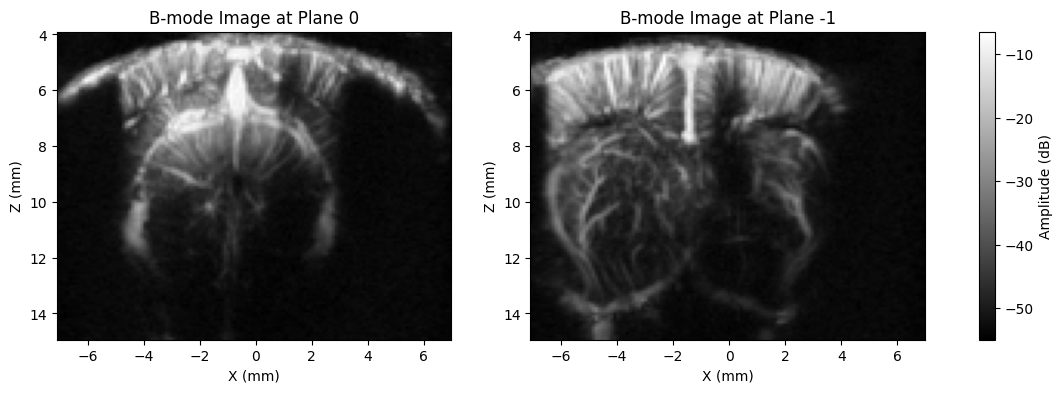

In [587]:
Bmode_dB = 20 * np.log10(np.abs(data3D_reshaped) / np.max(np.abs(data3D_reshaped)))
Bmode_dB = np.clip(Bmode_dB, -60, 0)
n_y = 2
fig, axs = plt.subplots(1, n_y, figsize=(14, 4))
axs = axs.flatten()
index = [0, -1]
for i in range(n_y):
    im = axs[i].imshow(Bmode_dB[:, index[i], :].squeeze().T, aspect='auto', cmap='gray',
                  extent=(vol_origin[0], vol_origin[0]+vol_dimensions[0] * vol_spacing[0],vol_origin[2]+ vol_dimensions[2] * vol_spacing[2], vol_origin[2]))
    axs[i].set_title(f'B-mode Image at Plane {index[i]}')
    axs[i].set_xlabel('X (mm)')
    axs[i].set_ylabel('Z (mm)')

fig.colorbar(im, ax=axs, orientation='vertical', label='Amplitude (dB)')
plt.show()


# 2. Qform and Sfrom affine matrix 

 Nifti specifies two coordinate transformations in the header of every image file:

- Qform is the coordinate transformation that takes the coordinates of the image into the coordinates of the scanner. For UltraSound images, the analagous is the transformation that allow us to get to the transducer space.
- Sform is a coordinate transformation that aligns the images to a standard reference, such us the volume anatomy for the subject. In our case, this is the transformation that allow us to align the images to the atlas model.

## 2.1. Qform  \(US voxel -> Transducer\)

### 2.2.1. Transducer space

Our world space will be the probe space. Then the center will be located at the center of the transducer, x-axis will be the lateral aperture of the transducer, y-axis corresponds to the height, and z-axis will grow towards the internal face of the transducer. Look at it

In [588]:
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer']


Transducer initialized in 0.0318 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


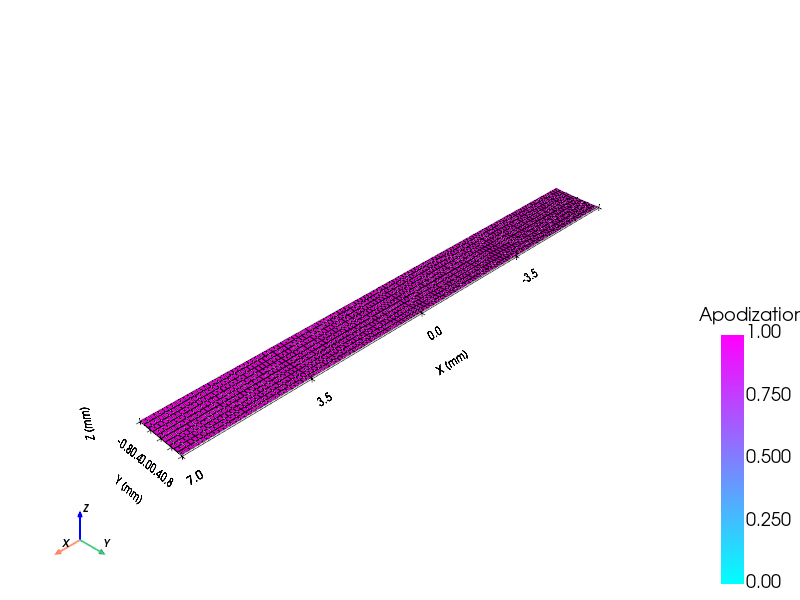

In [589]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)
domino.show(jupyter_backend='static')

In [590]:
TX_mesh = domino.get_mesh()

### 2.2.2. Creating Qform affine matrix

In [591]:
print("voxelsToProbe shape:\n", voxelsToProbe3D.shape)
print("probeToLab shape:\n", probeToLab3D.shape)

voxelsToProbe shape:
 (4, 4)
probeToLab shape:
 (43, 4, 4)


When then compute the matrix voxel to our transducer, what in the data they call to "lab"

In [592]:
voxels2Lab3D = probeToLab3D[0].squeeze() @ voxelsToProbe3D *1e3 # Convert to mm
print("voxels2Lab3D:\n", voxels2Lab3D)
invertz = np.diag([1, 1, -1, 1])  # Invert z-axis

voxels2Lab3D:
 [[ 1.10000e-01  0.00000e+00  0.00000e+00 -7.09500e+00]
 [ 0.00000e+00  2.00000e-01  0.00000e+00  4.80000e+00]
 [ 0.00000e+00  0.00000e+00 -9.85600e-02 -3.90144e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+03]]


In [593]:
qform = invertz @ voxels2Lab3D 
print("qform:\n", qform)

qform:
 [[ 1.10000e-01  0.00000e+00  0.00000e+00 -7.09500e+00]
 [ 0.00000e+00  2.00000e-01  0.00000e+00  4.80000e+00]
 [ 0.00000e+00  0.00000e+00  9.85600e-02  3.90144e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+03]]


### 2.2.3. Applying transformation to US data

we first initialize our generic data

In [594]:
# Create the 3D UniformGrid
fUS_voxels = pv.ImageData(
    dimensions = Bmode_dB.shape
)

# Attach pressure data to the grid
fUS_voxels.point_data["BMODE"] = Bmode_dB.ravel(order="F")  # VERY important: Fortran order

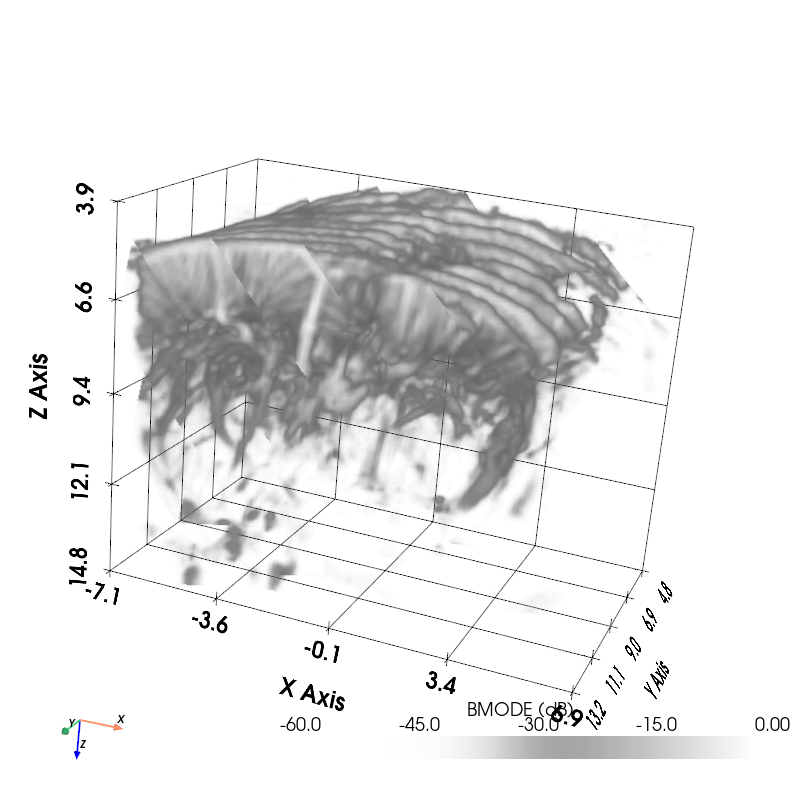

In [595]:
fUS_lab = fUS_voxels.copy()  #
fUS_lab.transform(qform, inplace=True)  # Apply the transformation to the image data

plotterUS = add_doppler_vol(fUS_lab, notebook=True, window_size=[800, 800], cmap="gray", opacity="sigmoid", clim=[-60, 0])
plotterUS.camera.up = (0, 0, -1)
plotterUS.camera_position = [(13.677126269681624, 47.4505641561841, -4.800695806578975),
 (-0.11000000000000032, 9.0, 9.37152),
 (-0.19185647928853963, -0.27811391376792133, -0.9411927232632515)]
plotterUS.show(jupyter_backend='static')

## 2.2. Sform (US voxel -> Brain Atlas reference)

### 2.2.1. Brain space

This brain space will be our standart reference to aligns acquisition during experiments. In this tutorial we'll be working on the rat model animal with the BrainGlobe atlases library. Let's import the libraries and visualize our reference.

In [596]:
from brainglobe_atlasapi import BrainGlobeAtlas

atlas_name = "whs_sd_rat_39um"
bg_atlas = BrainGlobeAtlas(atlas_name, check_latest=False)
print("Metadata:")
for key, value in bg_atlas.metadata.items():
    print(f"{key}: {value}")

Metadata:
name: whs_sd_rat
citation: Kleven et al 2023, https://doi.org/10.1038/s41592-023-02034-3
atlas_link: https://www.nitrc.org/projects/whs-sd-atlas
species: Rattus norvegicus
symmetric: False
resolution: [39.0, 39.0, 39.0]
orientation: asr
version: 1.2
shape: [1024, 512, 512]
trasform_to_bg: [[0.0, -1.0, 0.0, 39936.0], [0.0, 0.0, -1.0, 19968.0], [-1.0, 0.0, 0.0, 19968.0], [0.0, 0.0, 0.0, 1.0]]
additional_references: []
atlas_packager: Harry Carey, University of Oslo, Norway, harry.carey@medisin.uio.no


When you work with a stack, the origin is the upper left corner when you show the first element stack[0, :, :] with matplotlib or when you open the stack with ImageJ. The first dimension is the one that you are slicing, the second is the height of the image, and the third is the width of the image.

If the origin of your data (first, top left voxel) is the most anterior, superior, left part of the brain, then the orientation string would be “asl” (anterior, superior, left), and you would use asr. The order of the three initials must be the same as the axis order (sliced plane, height, width).

Following the NIFTI standards for coordinate systems, the original brain atlas (https://www.nitrc.org/projects/whs-sd-atlas/) is orientated in RAS+ (The order of the three initials must be the same as the axis order (x,y,z))., which means 

- The voxel X axis corresponds to the left-Right axis
- The voxel Y axis corresponds to the posterior-Anterior axis
- The voxel Z axis corresponds to the inferior-Superior axis

As one can see there is one affine matrix (rotation, translation and scaling all in one transformation matrix) on the `trasform_to_bg` entry of the metadata. This means that BrainGlobe has changed the orientation or the `space` of the original atlas. Let's check it up.

In [597]:
bg_atlas.space

<BGSpace AnatomicalSpace object>
origin: ('Anterior', 'Superior', 'Right')
sections: ('Frontal plane', 'Horizontal plane', 'Sagittal plane')
shape: (1024, 512, 512)

BrainGlobe defines the orientation by setting the origin. Thus, If the origin of your data is the most anterior, superior, right part of the brain, then the origin is set as “asr” (anterior, superior, right), which is the case of the BrainGlobeAtlas. Note that if the origin is set in the `asr` corner, then the *orientation* of your brain using the Nifti coordinate system is *PIL+*

- The voxel X axis corresponds to the anterior-Posterior axis
- The voxel Y axis corresponds to the superior-Inferior axis
- The voxel Z axis corresponds to the right-Left axis

Selected structure Root


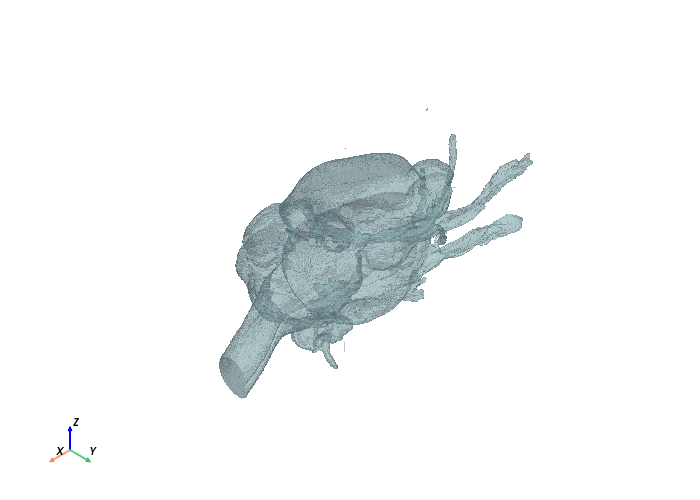

In [598]:
region_name = "root" 

# Get the PyVista mesh for the specified structure
pv_brain_mesh = get_pv_mesh_from_atlas(bg_atlas, region_name)

# Plot the structure mesh using PyVista
plotter = add_brain_mesh(pv_brain_mesh, 
                              window_size= [700, 500],
                              color="lightblue", 
                              opacity=0.5)
plotter.show_axes()
plotter.show(jupyter_backend='static',)

This BPS transformation is to be applied in a atlas with its origin in the most left-posterior-interior voxel, thus an atlas with orientation RAS+. 

In this moment, our BrainGlobe atlas has is origin in `asr`, then we must change the orientation of our atlas. `brainglobe_space` allow us to compute the affine matrix to go from one orientation to another by setting the target origin orientation.

In [599]:
import brainglobe_space as bg_space
# Now we create the target space 
target_space = bg_space.AnatomicalSpace("lpi") # New resolution to change the units from um to mm
trans_matrix_to_bps = bg_atlas.space.transformation_matrix_to(target_space)
print(trans_matrix_to_bps)

[[ 0.000e+00  0.000e+00 -1.000e+00  5.120e+02]
 [-1.000e+00  0.000e+00  0.000e+00  1.024e+03]
 [ 0.000e+00 -1.000e+00  0.000e+00  5.120e+02]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]


In the atlas paper publication we can retrieve the voxels of important

In [600]:
whs_origin_voxel = np.array([244, 623, 248])
bregma_voxel = np.array([246, 653, 440])
lambda_voxel = np.array([244, 442, 434])

resolution_um = np.array(bg_atlas.metadata['resolution']) # Convert to mm
resolution_mm = resolution_um*1e-3  # Convert to mm

bregma2lambda_mm = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_mm)
print("Bregma to Lambda distance in mm:", bregma2lambda_mm)

Bregma to Lambda distance in mm: 8.232695852513926


In [601]:
resolution2Voxel =  np.diag(np.concatenate((1/resolution_um, [1])))  # Add a 1 for homogeneous coordinates
set_whs_origin = np.eye(4)
set_whs_origin[:3, 3] = -whs_origin_voxel

bregma2lambda_um = np.linalg.norm((bregma_voxel - lambda_voxel) * resolution_um[0])
normalize_bregma2sigma_mm =  np.diag(np.concatenate(([resolution_mm[0]/bregma2lambda_mm]*3, [1])))  # Add a 1 for homogeneous coordinates
normalize_bregma2sigma_um =  np.diag(np.concatenate(([1/bregma2lambda_um]*3, [1])))  # Add a 1 for homogeneous coordinates

print("resolution2Voxel:\n", resolution2Voxel)
print("set_whs_origin:\n", set_whs_origin)
print("normalize_bregma2sigma:\n", normalize_bregma2sigma_mm)

resolution2Voxel:
 [[0.02564103 0.         0.         0.        ]
 [0.         0.02564103 0.         0.        ]
 [0.         0.         0.02564103 0.        ]
 [0.         0.         0.         1.        ]]
set_whs_origin:
 [[   1.    0.    0. -244.]
 [   0.    1.    0. -623.]
 [   0.    0.    1. -248.]
 [   0.    0.    0.    1.]]
normalize_bregma2sigma:
 [[0.00473721 0.         0.         0.        ]
 [0.         0.00473721 0.         0.        ]
 [0.         0.         0.00473721 0.        ]
 [0.         0.         0.         1.        ]]


In [602]:
# Transform the mesh to the new space
print("Brain2Lab:\n", BrainToLab)
Brain2Lab = BrainToLab * 1e3 # Convert to mm
Lab2Brain = np.linalg.inv(Brain2Lab)
print("Lab2Brain:\n", Lab2Brain)

Brain2Lab:
 [[ 7.30249668e-03 -7.49453668e-04  1.94281872e-04 -1.53600034e-03]
 [ 1.75873895e-04  7.93594891e-03  1.08144651e-05  1.27103552e-02]
 [-1.76348435e-05  2.26471207e-04  7.70593407e-03 -1.11717150e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Lab2Brain:
 [[ 1.36617994e-01  1.30007199e-02 -3.46265557e-03  5.91771665e-06]
 [-3.02823047e-03  1.25725753e-01 -1.00095131e-04 -1.60378858e-03]
 [ 4.01644231e-04 -3.66522696e-03  1.29765139e-01  1.49690242e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e-03]]


In [603]:
bg_atlas2bps_atlas =  normalize_bregma2sigma_mm @ set_whs_origin @ trans_matrix_to_bps @ resolution2Voxel #@  # 
print("bg2atlas:\n", bg_atlas2bps_atlas)

bg2atlas:
 [[ 0.00000000e+00  0.00000000e+00 -1.21466895e-04  1.26957198e+00]
 [-1.21466895e-04  0.00000000e+00  0.00000000e+00  1.89962077e+00]
 [ 0.00000000e+00 -1.21466895e-04  0.00000000e+00  1.25062315e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [604]:
bg_atlas2Lab = invertz @ Brain2Lab @ bg_atlas2bps_atlas

Looking in to the atlas information one can see that following the Nifty standars with orienation (RAS+) the bregma and the lambda are located in the following voxels

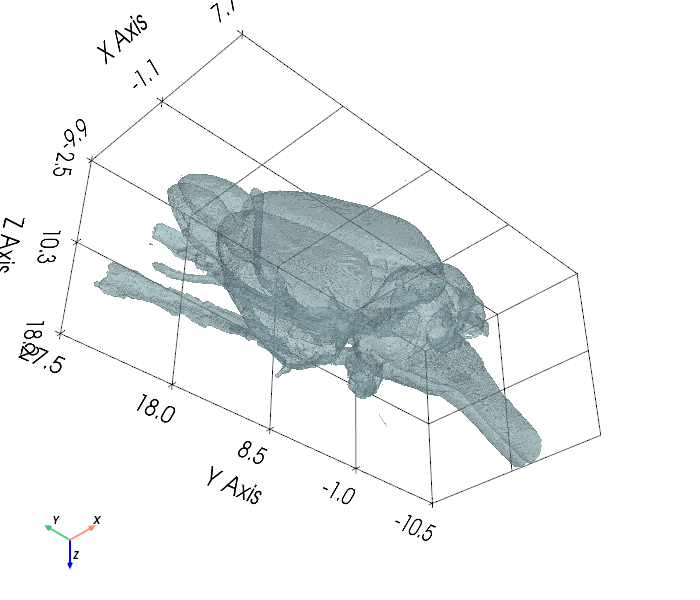

In [605]:
pv_brain_lab = pv_brain_mesh.copy()
pv_brain_lab .transform(bg_atlas2Lab, inplace=True)

plotter2 = add_brain_mesh(pv_brain_lab,
                    window_size= [700, 600],
                    color="lightblue", 
                    opacity=0.5)
plotter2.show_axes()
plotter2.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)
plotter2.camera.up = (0, 0, -1)
plotter2.show(jupyter_backend='static',)

### 1.3.1. Creating Sform affine matrix

In [606]:
# Then the final sform (voxel → brain) is:
sform = invertz @ Lab2Brain @ voxels2Lab3D   # Convert to mm
print("sform:\n", sform)

sform:
 [[ 1.50279794e-02  2.60014397e-03  3.41279333e-04 -8.87474154e-01]
 [-3.33105352e-04  2.51451505e-02  9.86537612e-06 -9.78429152e-01]
 [-4.41808654e-05  7.33045393e-04  1.27896521e-02 -9.70188758e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


c:\Users\deyve\Documents\PySonoGen\.venv\Lib\site-packages\pyvista\core\grid.py:1053: UserWarning: The transformation matrix has a shear component which has been removed. 
Shear is not supported when setting `ImageData` `index_to_physical_matrix`.
  warnings.warn(


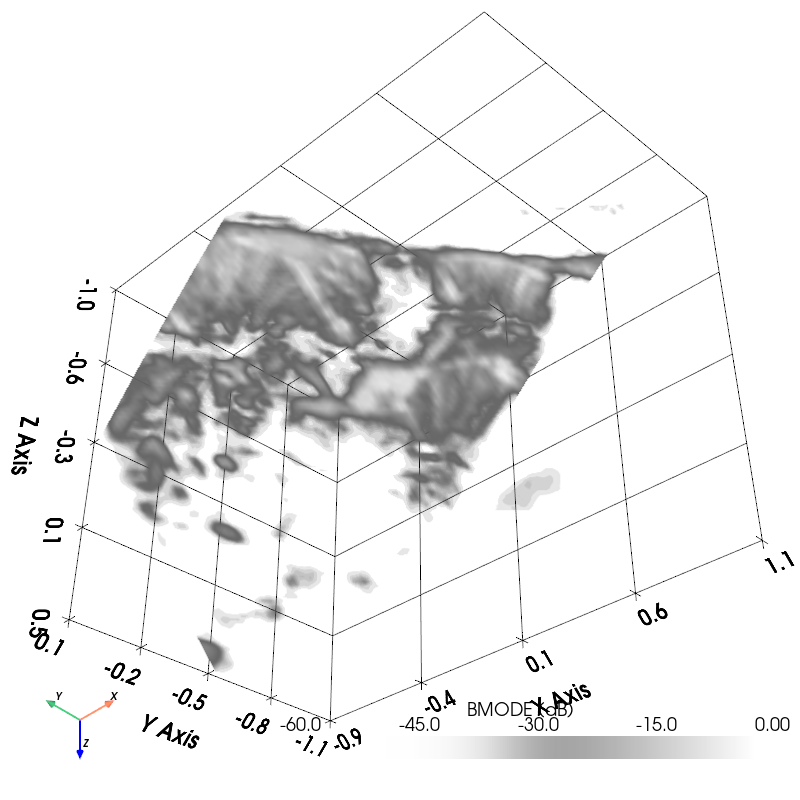

In [607]:
fUS_brain = fUS_voxels.copy()  #
fUS_brain.transform(sform, inplace=True)  # Apply the transformation to the image data

plotterUS2 = add_doppler_vol(fUS_brain, notebook=True, window_size=[800, 800], cmap="gray", opacity="sigmoid", clim=[-60, 0])
plotterUS2.camera.up = (0, 0, -1)
plotterUS2.show(jupyter_backend='static')

# 3. Final visualization

In [612]:
print("sform:\n", sform)
print("qform:\n", qform)

sform:
 [[ 1.50279794e-02  2.60014397e-03  3.41279333e-04 -8.87474154e-01]
 [-3.33105352e-04  2.51451505e-02  9.86537612e-06 -9.78429152e-01]
 [-4.41808654e-05  7.33045393e-04  1.27896521e-02 -9.70188758e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
qform:
 [[ 1.10000e-01  0.00000e+00  0.00000e+00 -7.09500e+00]
 [ 0.00000e+00  2.00000e-01  0.00000e+00  4.80000e+00]
 [ 0.00000e+00  0.00000e+00  9.85600e-02  3.90144e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+03]]


In [ ]:
final_plotter = pv.Plotter(notebook=False, window_size=[800, 800])

final_plotter = add_doppler_vol(fUS_lab,
                        plotter=final_plotter,
                        cmap="gray", 
                        opacity="sigmoid", 
                        clim=[-60, 0])

final_plotter = add_brain_mesh(pv_brain_lab,
                        plotter=final_plotter,
                        color="lightgrey", 
                        opacity=0.2)

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter)

final_plotter.camera.up = (0, 0, -1)
final_plotter.show_axes()
final_plotter.show_grid(
    bold =False, n_zlabels = 3, n_xlabels = 3
)

final_plotter.show()

